# Aprendizado por Reforço

---

**Professor:** Prof. Gabriel Lima  
**Aula:** 03  
**Exercício:** 3B  

---

### Objetivo :  
Utilizando o ambiente Frozen Lake da biblioteca Gymnasium implementar os algoritmos: 

- Iterative Policy Evaluation
- Policy Iteration

## Bibliotecas Utilizadas

Para a implementação dos algoritmos utilizaremos as seguintes bibliotecas: 

In [1]:
import matplotlib.pyplot as plt
from matplotlib import animation
import numpy as np
import gymnasium as gym

## Definição do Ambiente

**Regras:**  

O jogo inicia com o jogador na posição [0,0], onde o objetivo é chegar ao ponto [3,3].  

Buracos de gelo são distribuidos pelo grid. 

O jogador deve-se mover até atingir um estado terminal ( cair em um buraco ou chegar em seu objetivo).

Nesse exercício o ambiente poderá ser deterministico ou estocástico. is_slippery = True/False.  

**Recompensas:**

* Atingir o objetivo: +1
* Cair em um buraco : 0
* Demais estados    : 0

**Estados:**

![GIF](https://gymnasium.farama.org/_images/frozen_lake.gif)

In [ ]:
env = gym.make('FrozenLake-v1',render_mode='rgb_array',is_slippery=False)

Testando um estado:

In [17]:
env.unwrapped.P[1][0]

[(1.0, 0, 0.0, False)]

## Definindo a Política

Para cada estado o agente terá a probabilidade uniforme de executar uma ação:

In [5]:
random_policy = np.ones([env.observation_space.n, env.action_space.n]) / env.action_space.n

In [6]:
random_policy

array([[0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25]])

## Iterative Policy Evaluation

**Objetivo:** Estimar o valor dos estados sob uma política fixa 𝜋.

***Equação de Bellman para política fixa:***


Para todo estado s ∈ 𝒮:

**V(s) = ∑ₐ π(a│s) ∑ₛ′ 𝒫ₛₛ′ᵃ [ ℛ(s, a) + γ V(s′) ]**

### Algoritmo:

**Entrada:**
- Política 𝜋
- Função de transição 𝒫
- Função de recompensa ℛ
- Fator de desconto γ
- Limite de tolerância θ

**Inicialização:**
- V(s) ← valor arbitrário (ex: 0), ∀ s ∈ 𝒮

**Repetir:**
1. Δ ← 0  
2. Para cada estado s ∈ 𝒮:  
   a. v ← V(s)  
   b. V(s) ← ∑ₐ π(a│s) ∑ₛ′ 𝒫ₛₛ′ᵃ [ ℛ(s, a) + γ V(s′) ]  
   c. Δ ← max(Δ, |v − V(s)|)  
3. Até que Δ < θ

**Saída:**  
- Função de valor V(s) para todos os estados sob a política 𝜋

In [4]:
def policy_evaluation(env, policy, gamma, theta=1e-8):
    V = np.zeros(env.observation_space.n)
    while True:
        delta = 0
        for s in range(env.observation_space.n):
            Vs = 0
            for a, action_prob in enumerate(policy[s]):
                for prob, next_state, reward, done in env.unwrapped.P[s][a]:
                    Vs += action_prob * prob * (reward + gamma * V[next_state])
            delta = max(delta, np.abs(V[s]-Vs))
            V[s] = Vs
        if delta < theta:
            break
    return V

In [7]:
V = policy_evaluation(env, random_policy,0.99)

### Visualização

In [8]:
def plot_values(V):
	# reshape value function
  V_sq = np.reshape(V, (4,4))

	# plot the state-value function
  fig = plt.figure(figsize=(6, 6))
  ax = fig.add_subplot(111)
  im = ax.imshow(V_sq, cmap='cool')
  for (j,i),label in np.ndenumerate(V_sq):
      ax.text(i, j, np.round(label, 5), ha='center', va='center', fontsize=14)
  plt.tick_params(bottom='off', left='off', labelbottom='off', labelleft='off')
  plt.title('State-Value Function')
  plt.show()

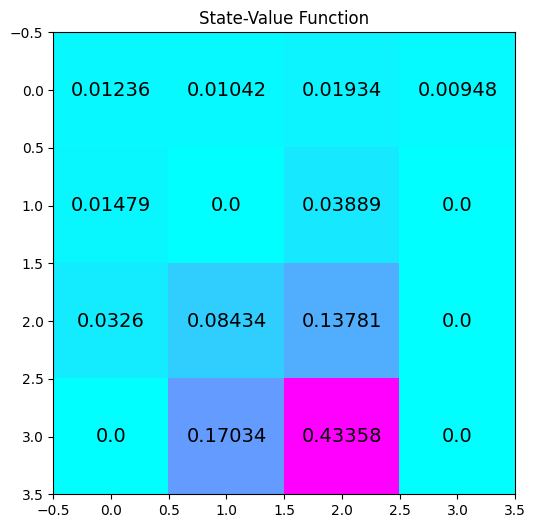

In [9]:
plot_values(V)

## Cálculo de Q (ação-valor)

In [ ]:
def q_from_v(env, V, s, gamma):
    q = np.zeros(env.action_space.n)
    for a in range(env.action_space.n):
        for prob, next_state, reward, _ in env.unwrapped.P[s][a]:
            q[a] += prob * (reward + gamma * V[next_state])
    return q

Para cada ação `a` disponível no estado `s`, o Q-valor é calculado como:

**Q(s, a) = ∑ₛ′ 𝒫(s′│s, a) · [ ℛ(s, a, s′) + γ · V(s′) ]**

Ou seja:
- Percorremos todos os pares (probabilidade, próximo estado, recompensa) definidos pelo ambiente para a ação `a` em `s`
- Acumulamos a expectativa do retorno descontado

In [11]:
q_from_v(env,V,1,0.99)

array([0.00751758, 0.0104592 , 0.00982175, 0.01389926])

## Policy Iteration

**Objetivo:** Encontrar a política ótima 𝜋* por meio de iterações de avaliação e melhoria de política.

***Etapas principais:***

1. **Avaliação de Política (Policy Evaluation)**  
   Utiliza a Equação de Bellman para uma política fixa:
   
   **V(s) = ∑ₐ π(a│s) ∑ₛ′ 𝒫ₛₛ′ᵃ [ ℛ(s, a) + γ V(s′) ]**

2. **Melhoria de Política (Policy Improvement)**  
   Atualiza a política escolhendo a melhor ação com base em V(s):

   **π′(s) = argmaxₐ ∑ₛ′ 𝒫ₛₛ′ᵃ [ ℛ(s, a) + γ V(s′) ]**

### Algoritmo:

**Entrada:**
- Função de transição 𝒫
- Função de recompensa ℛ
- Conjunto de ações 𝒜
- Fator de desconto γ
- Tolerância θ para a avaliação de política

**Inicialização:**
- Inicializar π(s) arbitrariamente para todos s ∈ 𝒮  
- Inicializar V(s) arbitrariamente (ex: 0) para todos s ∈ 𝒮

**Repetir:**
1. **[Policy Evaluation]**  
   - Usar Iterative Policy Evaluation para calcular V(s) sob π até convergência (Δ < θ)

2. **[Policy Improvement]**  
   - policy_stable ← True  
   - Para cada estado s ∈ 𝒮:  
     a. a_old ← π(s)  
     b. π(s) ← argmaxₐ ∑ₛ′ 𝒫ₛₛ′ᵃ [ ℛ(s, a) + γ V(s′) ]  
     c. Se a_old ≠ π(s): policy_stable ← False

3. Até que policy_stable seja **True**

**Saída:**  
- Política ótima 𝜋*  
- Função de valor V* associada

In [12]:
def policy_improvement(env, V, gamma):
    policy = np.zeros([env.observation_space.n, env.action_space.n]) / env.action_space.n

    for s in range(env.observation_space.n):
        q = q_from_v(env, V, s, gamma)

        # construct a stochastic policy that puts equal probability on maximizing actions
        best_a = np.argwhere(q==np.max(q)).flatten()
        policy[s] = np.sum([np.eye(env.action_space.n)[i] for i in best_a], axis=0)/len(best_a)

    return policy

In [13]:
def policy_iteration(env, gamma=1, theta=1e-8):
    policy = np.ones([env.observation_space.n, env.action_space.n]) / env.action_space.n
    while True:
        V = policy_evaluation(env, policy, gamma, theta)
        new_policy = policy_improvement(env, V,gamma)

        # OPTION 1: stop if the policy is unchanged after an improvement step
        if (new_policy == policy).all():
            break

        # OPTION 2: stop if the value function estimates for successive policies has converged
        # if np.max(abs(policy_evaluation(env, policy) - policy_evaluation(env, new_policy))) < theta*1e2:
        #    break;

        policy = np.copy(new_policy)
    return policy, V

In [14]:
policy_pi, V_pi = policy_iteration(env=env,gamma=0.99)

In [19]:
print("\nOptimal Policy (LEFT = 0, DOWN = 1, RIGHT = 2, UP = 3):")
print(policy_pi,"\n")


Optimal Policy (LEFT = 0, DOWN = 1, RIGHT = 2, UP = 3):
[[1.   0.   0.   0.  ]
 [0.   0.   0.   1.  ]
 [0.   0.   0.   1.  ]
 [0.   0.   0.   1.  ]
 [1.   0.   0.   0.  ]
 [0.25 0.25 0.25 0.25]
 [0.5  0.   0.5  0.  ]
 [0.25 0.25 0.25 0.25]
 [0.   0.   0.   1.  ]
 [0.   1.   0.   0.  ]
 [1.   0.   0.   0.  ]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.   0.   1.   0.  ]
 [0.   1.   0.   0.  ]
 [0.25 0.25 0.25 0.25]] 



### Visualização

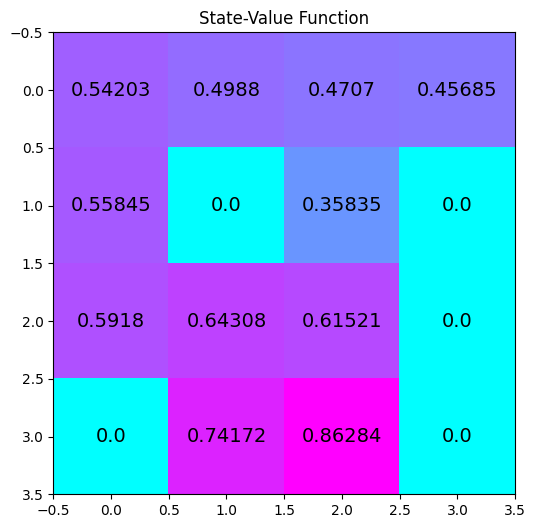

In [20]:
plot_values(V_pi)